In [1]:
import pandas as pd
import numpy as np

In [81]:
df = pd.read_csv('../data/case_data.csv')

,product,source
0,butter,zuivelnl
1221,milk,belgium
1806,butter,eex eu
4588,smp,eex eu


In [ ]:
df['source'] = df['source'].str.lower().str.strip()
df['product'] = df['product'].str.lower().str.strip()
df['ts_name'] = df['product'] + ' - ' + df['source']
df[['product', 'source']].drop_duplicates()

array(['butter - zuivelnl', 'milk - belgium', 'butter - eex eu',
       'smp - eex eu'], dtype=object)

In [86]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True).dt.date
df[df['ts_name'] == 'butter - zuivelnl'][['ts_name', 'date', 'price']].sort_values('date')

,ts_name,date,price
0,butter - zuivelnl,2001-04-23,3131.08
1,butter - zuivelnl,2001-04-30,3153.77
2,butter - zuivelnl,2001-05-07,3153.77
3,butter - zuivelnl,2001-05-14,3221.84
4,butter - zuivelnl,2001-05-21,3221.84
...,...,...,...
1216,butter - zuivelnl,2025-09-24,5500.00
1217,butter - zuivelnl,2025-10-01,5440.00
1218,butter - zuivelnl,2025-10-08,5440.00
1219,butter - zuivelnl,2025-10-15,5330.00


In [46]:
df[df.id == 2878133]

,id,date,price,product,source,ts_name
1216,2878133,2025-09-24,5500.0,butter,zuivelnl,butter - zuivelnl


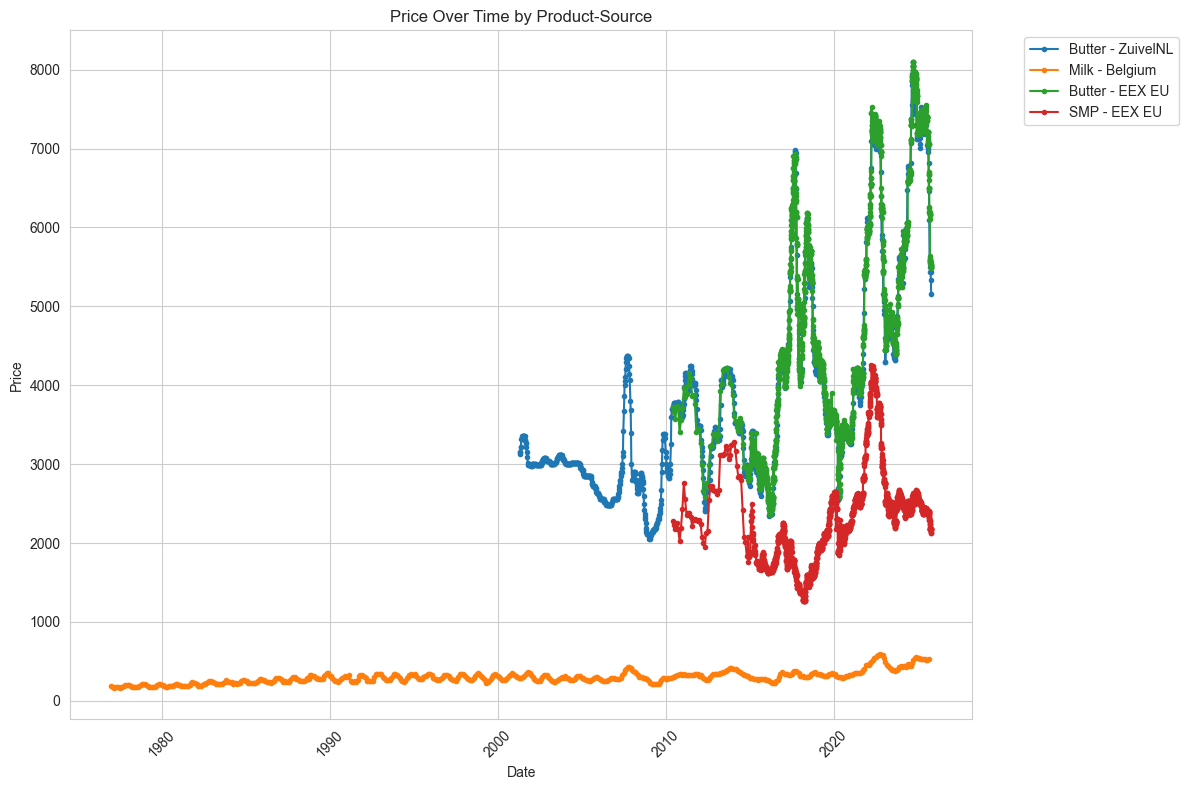

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot style
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Create line plot for each ts_name
for ts_name in df['ts_name'].unique():
    subset = df[df['ts_name'] == ts_name]
    plt.plot(subset['date'], subset['price'], label=ts_name, marker='o', markersize=3)

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Price Over Time by Product-Source')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
df.groupby('ts_name')['date'].count()

ts_name
Butter - EEX EU      2782
Butter - ZuivelNL    1221
Milk - Belgium        585
SMP - EEX EU         2756
Name: date, dtype: int64

In [22]:
df = df.sort_values(by=['ts_name', 'date'])
df['date_diff'] = df.groupby('ts_name')['date'].diff()
mean_date_diff = df.groupby('ts_name')['date_diff'].mean()
std_date_diff = df.groupby('ts_name')['date_diff'].std()
print(mean_date_diff)
print(std_date_diff)

ts_name
Butter - EEX EU      2 days 00:31:35.145631067
Butter - ZuivelNL    7 days 08:01:34.426229508
Milk - Belgium      30 days 10:28:46.027397260
SMP - EEX EU         2 days 00:59:03.811252268
Name: date_diff, dtype: timedelta64[ns]
ts_name
Butter - EEX EU     4 days 02:02:58.906162749
Butter - ZuivelNL   1 days 16:03:20.649567197
Milk - Belgium      0 days 19:37:15.016321050
SMP - EEX EU        4 days 04:02:07.469778045
Name: date_diff, dtype: timedelta64[ns]


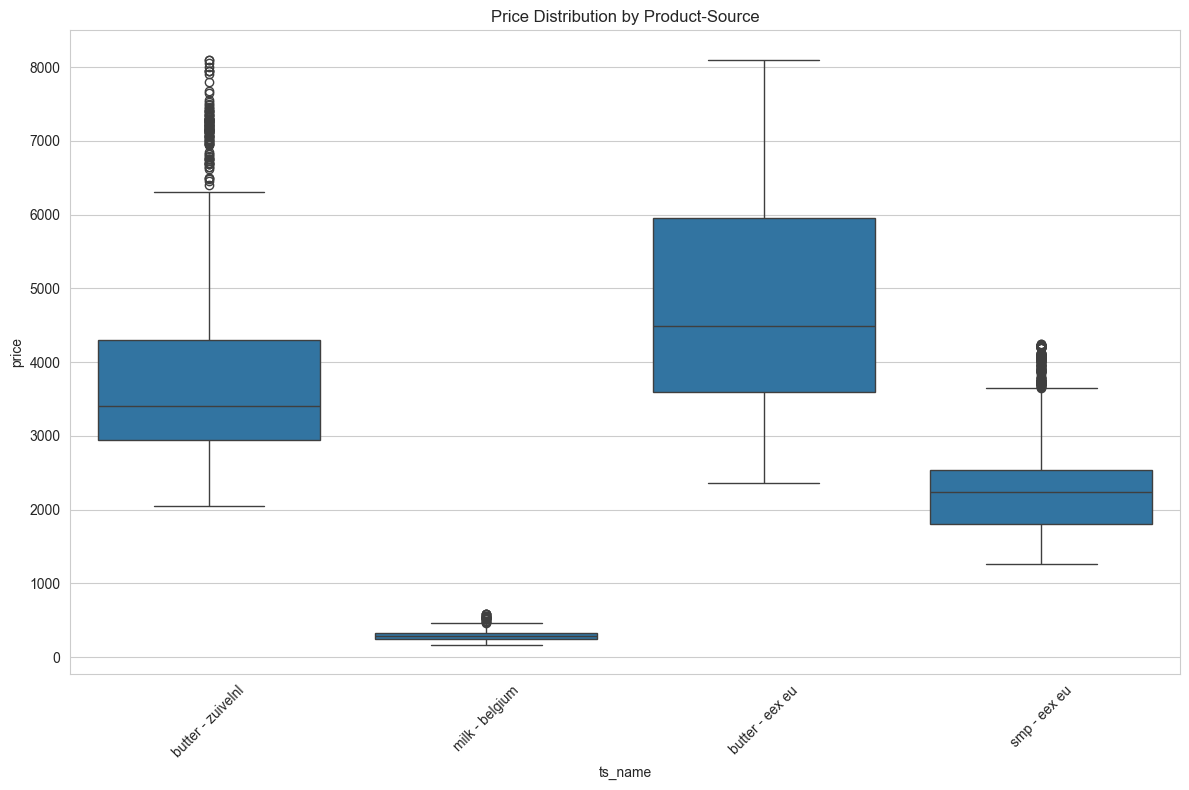

In [99]:
df.groupby("ts_name")['price'].describe()
#plot the price distributions for each ts_name
plt.figure(figsize=(12, 8))
sns.boxplot(x='ts_name', y='price', data=df)
plt.xticks(rotation=45)
plt.title('Price Distribution by Product-Source')
plt.tight_layout()
plt.show()

In [ ]:
print(df[df['price'].isnull()])

Empty DataFrame
Columns: [id, date, price, product, source, ts_name]
Index: []


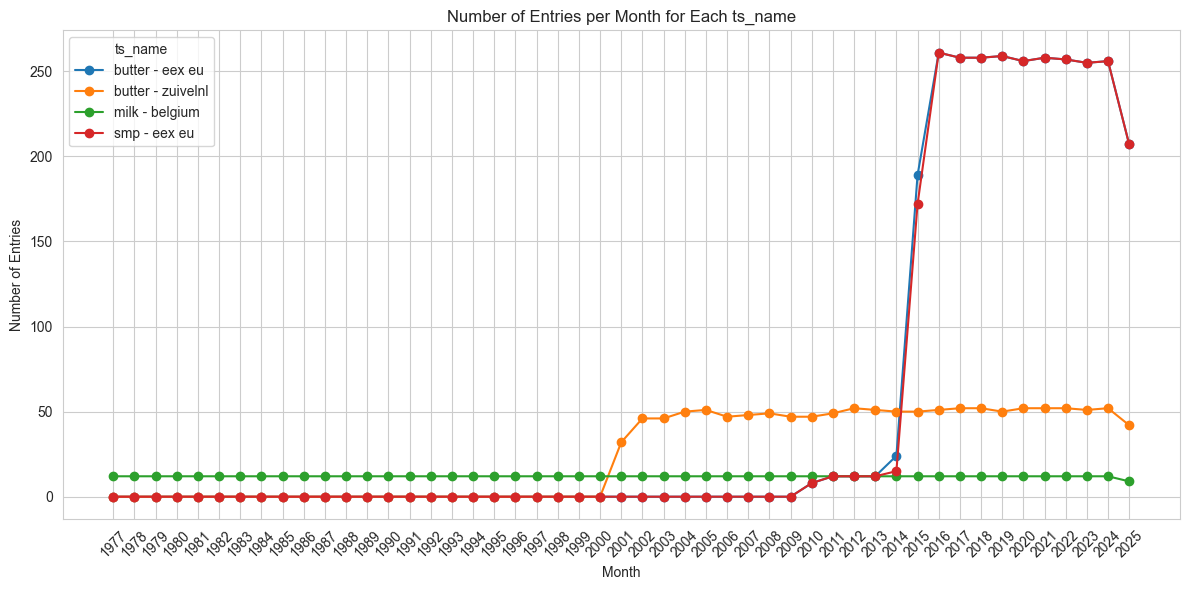

In [ ]:
# Plot the number of entries per year for all ts_name as line plot
df['year'] = pd.to_datetime(df['date']).dt.year
yearly_counts = df.groupby(['year', 'ts_name']).size().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(12, 6))
for ts_name in yearly_counts.columns:
    plt.plot(yearly_counts.index.astype(str), yearly_counts[ts_name], marker='o', label=ts_name)

plt.title('Number of Entries per year for Each ts_name')
plt.xlabel('Month')
plt.ylabel('Number of Entries')
plt.xticks(rotation=45)
plt.legend(title='ts_name')
plt.tight_layout()
plt.show()

SEASONALITY ANALYSIS RESULTS

BUTTER - ZUIVELNL:
  Seasonal pattern detected: NO
  ANOVA p-value: 0.5053
  Monthly averages:
    Month 1: $3667.21 (±$1177.07, n=104.0)
    Month 2: $3675.48 (±$1204.68, n=93.0)
    Month 3: $3742.12 (±$1302.22, n=104.0)
    Month 4: $3791.60 (±$1432.66, n=103.0)
    Month 5: $3816.03 (±$1422.43, n=107.0)
    Month 6: $3965.01 (±$1504.20, n=104.0)
    Month 7: $4026.48 (±$1457.07, n=108.0)
    Month 8: $3984.07 (±$1500.79, n=108.0)
    Month 9: $3995.05 (±$1498.85, n=105.0)
    Month 10: $4008.40 (±$1351.09, n=106.0)
    Month 11: $3906.53 (±$1290.53, n=95.0)
    Month 12: $3826.43 (±$1207.42, n=84.0)

MILK - BELGIUM:
  Seasonal pattern detected: YES
  ANOVA p-value: 0.0008
  Monthly averages:
    Month 1: $312.41 (±$74.03, n=49.0)
    Month 2: $306.20 (±$71.63, n=49.0)
    Month 3: $293.74 (±$74.11, n=49.0)
    Month 4: $282.58 (±$76.03, n=49.0)
    Month 5: $277.78 (±$77.24, n=49.0)
    Month 6: $277.30 (±$79.76, n=49.0)
    Month 7: $277.69 (±$78.10, 

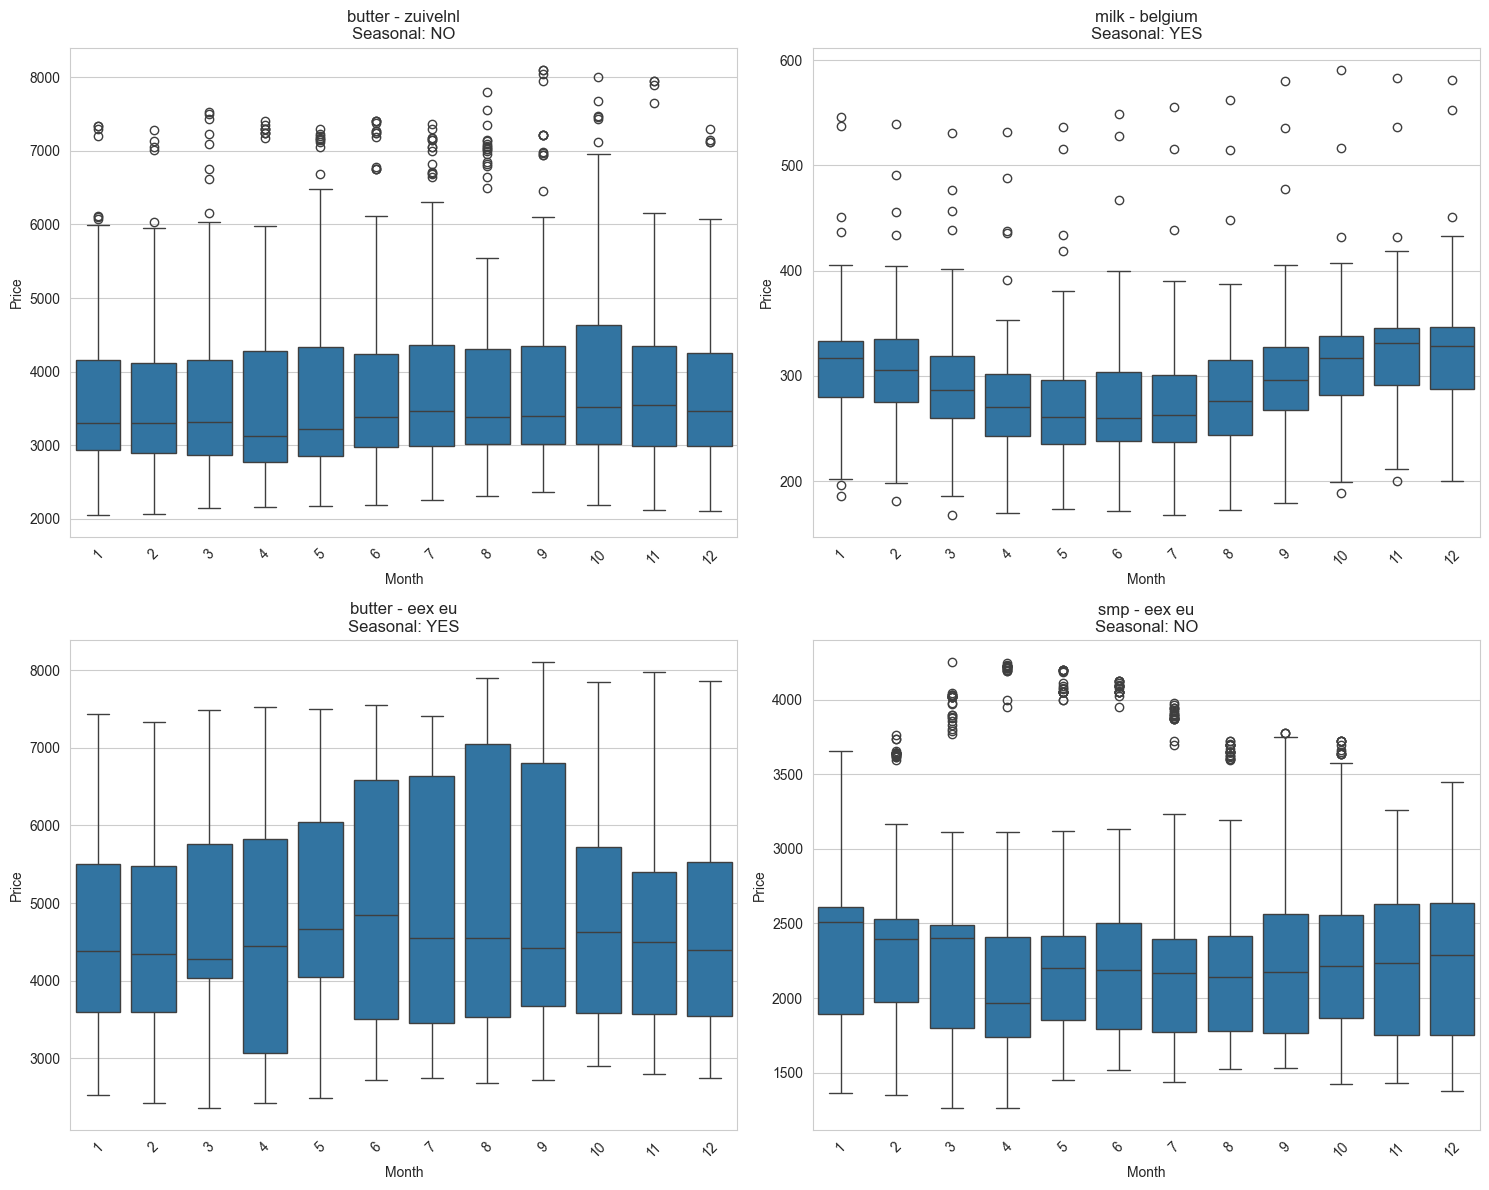



SEASONALITY SUMMARY TABLE
             ts_name  is_seasonal  p_value  highest_month  lowest_month  \
0  butter - zuivelnl        False   0.5053              7             1   
1     milk - belgium         True   0.0008             12             6   
2    butter - eex eu         True   0.0000              9             2   
3       smp - eex eu        False   0.4036             12             8   

   price_range  cv_seasonal  
0     359.2699       3.3880  
1      49.5291       6.2729  
2     523.0124       3.9192  
3     123.3174       1.8018  


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Ensure date is datetime for seasonal analysis
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['year'] = df['date'].dt.year

# Function to analyze seasonality for each ts_name
def analyze_seasonality(ts_name_data, ts_name):
    """Analyze seasonal patterns in price data"""
    
    # Monthly analysis
    monthly_stats = ts_name_data.groupby('month')['price'].agg(['mean', 'std', 'count'])
    
    # Quarterly analysis
    quarterly_stats = ts_name_data.groupby('quarter')['price'].agg(['mean', 'std', 'count'])
    
    # Statistical test for seasonality (ANOVA)
    try:
        groups = [ts_name_data[ts_name_data['month'] == month]['price'].values 
                 for month in ts_name_data['month'].unique() if len(ts_name_data[ts_name_data['month'] == month]) > 1]
        if len(groups) > 1:
            f_stat, p_value = stats.f_oneway(*groups)
        else:
            f_stat, p_value = np.nan, np.nan
    except:
        f_stat, p_value = np.nan, np.nan
    
    return {
        'ts_name': ts_name,
        'monthly_stats': monthly_stats,
        'quarterly_stats': quarterly_stats,
        'anova_f_stat': f_stat,
        'anova_p_value': p_value,
        'is_seasonal': p_value < 0.05 if not np.isnan(p_value) else False
    }

# Analyze seasonality for each ts_name
seasonality_results = {}
for ts_name in df['ts_name'].unique():
    ts_data = df[df['ts_name'] == ts_name].copy()
    if len(ts_data) > 10:  # Only analyze if we have enough data points
        seasonality_results[ts_name] = analyze_seasonality(ts_data, ts_name)

# Display results
print("SEASONALITY ANALYSIS RESULTS")
print("=" * 50)

for ts_name, result in seasonality_results.items():
    print(f"\n{ts_name.upper()}:")
    print(f"  Seasonal pattern detected: {'YES' if result['is_seasonal'] else 'NO'}")
    print(f"  ANOVA p-value: {result['anova_p_value']:.4f}" if not np.isnan(result['anova_p_value']) else "  ANOVA p-value: N/A")
    
    print("  Monthly averages:")
    for month, stats in result['monthly_stats'].iterrows():
        print(f"    Month {month}: ${stats['mean']:.2f} (±${stats['std']:.2f}, n={stats['count']})")

# Visualization: Monthly price patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (ts_name, result) in enumerate(seasonality_results.items()):
    if i >= 4:  # Limit to 4 plots
        break
    
    ts_data = df[df['ts_name'] == ts_name]
    
    # Monthly boxplot
    ax = axes[i]
    sns.boxplot(data=ts_data, x='month', y='price', ax=ax)
    ax.set_title(f'{ts_name}\nSeasonal: {"YES" if result["is_seasonal"] else "NO"}')
    ax.set_xlabel('Month')
    ax.set_ylabel('Price')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary table
summary_data = []
for ts_name, result in seasonality_results.items():
    monthly_mean = result['monthly_stats']['mean']
    summary_data.append({
        'ts_name': ts_name,
        'is_seasonal': result['is_seasonal'],
        'p_value': result['anova_p_value'],
        'highest_month': monthly_mean.idxmax(),
        'lowest_month': monthly_mean.idxmin(),
        'price_range': monthly_mean.max() - monthly_mean.min(),
        'cv_seasonal': (monthly_mean.std() / monthly_mean.mean()) * 100  # Coefficient of variation
    })

summary_df = pd.DataFrame(summary_data)
print("\n\nSEASONALITY SUMMARY TABLE")
print("=" * 80)
print(summary_df.round(4))

In [73]:
!uv run pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 20.2 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [75]:
import requests

# Simple function to chat with the API
def chat_with_bot(message, thread_id=None, user_id=None):
    url = "http://localhost:8000/chat"
    data = {"message": message}
    
    if user_id:
        data["user_id"] = user_id
    if thread_id:
        data["thread_id"] = thread_id
    
    response = requests.post(url, json=data)
    
    if response.status_code == 200:
        result = response.json()
        print(f"Bot: {result['response']}")
        return result['user_id'], result['thread_id']
    else:
        print(f"Error: {response.text}")
        return None, None

# Usage examples:
user_id, thread_id = chat_with_bot("Is there a seasonal trend in the price of butter from zuivelnl?")



Bot: No data was found for the seasonal trend in the price of butter from ZuivelNL.


In [ ]:
'''
thread_id = chat_with_bot("What is the price of butter from Belgium?")
thread_id = chat_with_bot("Compare the average prices of milk and butter this year", thread_id)
thread_id = chat_with_bot("What about SMP from EEX EU?", thread_id)
thread_id = chat_with_bot("Show me the volatility of milk prices", thread_id)
'''

In [94]:
thread_id = chat_with_bot("Are there seasonal trends in the prices of milk, butter, and SMP from their respective sources?")

Bot: Based on the data retrieved from the price_food_commodities_transform table, here are the average prices of milk, butter, and SMP from their respective sources across the months:

- **Milk (Belgium)**
  - January: €312.41
  - February: €306.20
  - March: €293.74
  - April: €282.58
  - May: €277.78
  - June: €277.30
  - July: €277.69
  - August: €286.76
  - September: €302.96
  - October: €315.60
  - November: €326.31
  - December: €326.83

- **Butter (EEX EU)**
  - January: €4611.33
  - February: €4539.29
  - March: €4667.02
  - April: €4694.75
  - May: €4915.87
  - June: €5055.70
  - July: €4931.56
  - August: €5052.33
  - September: €5062.30
  - October: €4897.66
  - November: €4765.84
  - December: €4640.58

- **Butter (ZuivelNL)**
  - January: €3667.21
  - February: €3675.48
  - March: €3742.12
  - April: €3791.60
  - May: €3816.03
  - June: €3965.01
  - July: €4026.48
  - August: €3984.07
  - September: €3995.05
  - October: €4008.40
  - November: €3906.53
  - December: €3826

In [91]:
df[df['ts_name'] == 'milk - belgium'][['date', 'price']].sort_values('date', ascending=False)

,date,price
1805,2025-09-01,535.8
1804,2025-08-01,514.9
1803,2025-07-01,515.8
1802,2025-06-01,527.8
1801,2025-05-01,536.2
...,...,...
1225,1977-05-01,173.2
1224,1977-04-01,169.5
1223,1977-03-01,167.9
1222,1977-02-01,181.3
